# 📦 Data Collector — CartPole-v1

Collecte **100 000 steps**, politique mixte.

Outputs (1 fichier par type, splits intégrés) :
- `transitions.npz`
- `sequences_n5.npz`
- `deltas.npz`
- `scaler.npz`
- `metadata.json`

## 1. Imports & Configuration

In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os, json, random
from collections import deque
from datetime import datetime


ENV_NAME      = "CartPole-v1"
TOTAL_STEPS   = 100_000
N_STEPS       = 5
SAVE_DIR      = "collected/CartPole"
TRAIN_RATIO   = 0.70
VAL_RATIO     = 0.10
TEST_RATIO    = 0.20

TRAINED_RATIO = 0.6
LR            = 5e-4
GAMMA         = 0.99
EPSILON_START = 1.0
EPSILON_END   = 0.05
EPSILON_DECAY = 0.997
BATCH_SIZE    = 128
BUFFER_SIZE   = 50_000
TARGET_UPDATE = 300
TRAIN_START   = 1_000
SEED          = 42

os.makedirs(SAVE_DIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"  Config OK — {ENV_NAME} | {TOTAL_STEPS:,} steps | n={N_STEPS}")

✅ Config OK — CartPole-v1 | 100,000 steps | n=5


## 2. Environnement

In [ ]:
env = gym.make(ENV_NAME)
env.action_space.seed(SEED)

STATE_DIM    = env.observation_space.shape[0]   # 4
ACTION_DIM   = env.action_space.n               # 2
STATE_LABELS  = ["x (position)", "ẋ (vitesse)", "θ (angle)", "θ̇ (vit. ang.)"]
ACTION_LABELS = ["gauche (0)", "droite (1)"]

print(f" {ENV_NAME}  |  state={STATE_DIM}D  |  actions={ACTION_DIM}")
for i, lbl in enumerate(STATE_LABELS):
    lo, hi = env.observation_space.low[i], env.observation_space.high[i]
    print(f"   dim {i}: {lbl:18s} [{lo:.3f}, {hi:.3f}]")

🎮 CartPole-v1  |  state=4D  |  actions=2
   dim 0: x (position)       [-4.800, 4.800]
   dim 1: ẋ (vitesse)        [-inf, inf]
   dim 2: θ (angle)          [-0.419, 0.419]
   dim 3: θ̇ (vit. ang.)     [-inf, inf]


## 3. DQN

In [ ]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64), 
            nn.ReLU(),
            nn.Linear(64, 64),       
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
    def forward(self, x): 
        return self.net(x)


class ReplayBuffer:

    def __init__(self, cap):
        self.buf = deque(maxlen=cap)

    def push(self, s, a, r, ns, d):
        self.buf.append((s, a, r, ns, d))

    def sample(self, n):
        b = random.sample(self.buf, n)
        s,a,r,ns,d = zip(*b)
        return (torch.FloatTensor(np.array(s)), 
                torch.LongTensor(a),
                torch.FloatTensor(r), 
                torch.FloatTensor(np.array(ns)),
                torch.FloatTensor(d))
    
    def __len__(self): 
        return len(self.buf)

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
q_net      = QNetwork(STATE_DIM, ACTION_DIM).to(device)
target_net = QNetwork(STATE_DIM, ACTION_DIM).to(device)
target_net.load_state_dict(q_net.state_dict())
optimizer  = optim.Adam(q_net.parameters(), lr=LR)
replay_buf = ReplayBuffer(BUFFER_SIZE)
epsilon    = EPSILON_START
print(f" DQN sur {device} | params={sum(p.numel() for p in q_net.parameters()):,}")

🧠 DQN sur cpu | params=4,610


## 4. Helpers

In [ ]:
def select_action(state, eps, use_trained=True):

    if not use_trained or random.random() < eps:
        return env.action_space.sample()
    with torch.no_grad():
        return q_net(torch.FloatTensor(state).unsqueeze(0).to(device)).argmax(1).item()

def train_step():

    if len(replay_buf) < BATCH_SIZE: 
        return None
    s,a,r,ns,d = [x.to(device) for x in replay_buf.sample(BATCH_SIZE)]
    
    q = q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        best = q_net(ns).argmax(1, keepdim=True)
        tgt  = r + GAMMA * target_net(ns).gather(1,best).squeeze(1) * (1-d)

    loss = nn.SmoothL1Loss()(q, tgt)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(q_net.parameters(), 1.0)
    optimizer.step()
    return loss.item()


print(" Helpers définis")

✅ Helpers définis


## 5. Collecte Principale — 100 000 Steps

In [ ]:
all_episodes, cur_ep = [], []
step_count = episode_count = 0
ep_reward  = 0
rewards_log, random_rewards_log = [], []


state, _ = env.reset(seed=SEED)
print(f"🚀 Collecte {TOTAL_STEPS:,} steps...")
print("-"*65)

while step_count < TOTAL_STEPS:
    use_trained = (random.random() < TRAINED_RATIO) and (step_count >= TRAIN_START)
    action      = select_action(state, epsilon, use_trained)

    ns, reward, term, trunc, _ = env.step(action)
    done = term or trunc

    cur_ep.append(dict(state=state.copy(), action=int(action),
                       reward=float(reward), next_state=ns.copy(), done=bool(done),episode_id=episode_count))

    replay_buf.push(state, action, reward, ns, float(done))
    if step_count >= TRAIN_START: train_step()
    if step_count % TARGET_UPDATE == 0:
        target_net.load_state_dict(q_net.state_dict())

    ep_reward += reward
    state       = ns
    step_count += 1

    if done:
        all_episodes.append(cur_ep)
        rewards_log.append(ep_reward)
        cur_ep = []; ep_reward = 0; episode_count += 1
        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
        state, _ = env.reset()
        if episode_count % 50 == 0:
            avg = np.mean(rewards_log[-50:])
            print(f"  ep {episode_count:4d} | steps {step_count:7,} | avg50={avg:7.1f} | ε={epsilon:.3f}")

if cur_ep  and cur_ep[-1]["done"]: all_episodes.append(cur_ep)
env.close()
print("-"*65)
print(f"{step_count:,} steps | {episode_count} épisodes | reward_mean={np.mean(rewards_log):.2f}, reward_max={np.max(rewards_log):.2f}")

🚀 Collecte 100,000 steps...
-----------------------------------------------------------------


NameError: name 'safe_copy' is not defined

## 6. Learning Curve

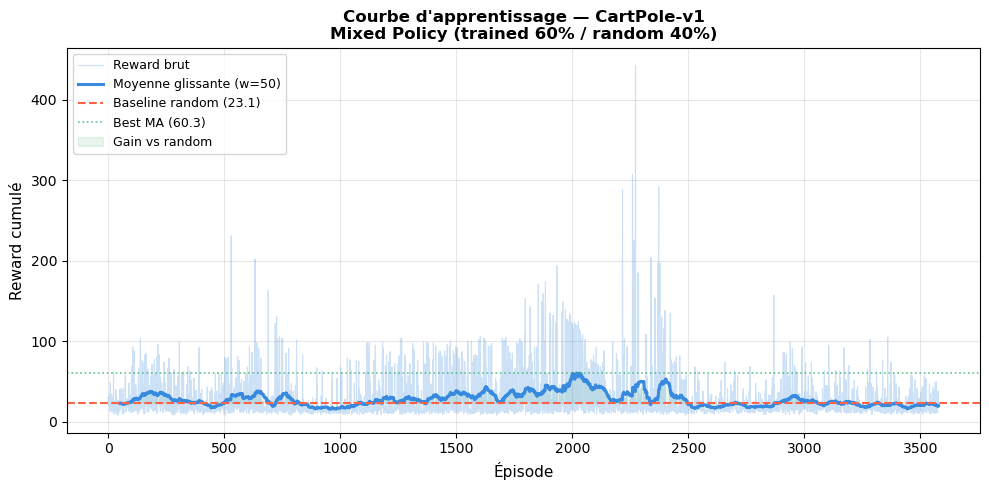

📈 Learning curve sauvegardée → collected/CartPole/learning_curve.png


In [ ]:
def plot_learning_curve(rewards, window=50, env_name=ENV_NAME, save_dir=SAVE_DIR):

    rewards = np.array(rewards)
    episodes = np.arange(len(rewards))

    ma = np.convolve(rewards, np.ones(window)/window, mode='valid')
    ma_ep = episodes[window-1:]

    n_random = max(1, sum(1 for _ in range(episode_count) if _ * (TOTAL_STEPS//episode_count) < TRAIN_START))
    random_baseline = float(np.mean(rewards[:max(10, n_random)]))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(episodes, rewards, alpha=0.25, color="#378ADD", linewidth=0.8, label="Reward brut")
    ax.plot(ma_ep, ma, color="#378ADD", linewidth=2.2, label=f"Moyenne glissante (w={window})")
    ax.axhline(random_baseline, color="tomato", linestyle="--", linewidth=1.5,
               label=f"Baseline random ({random_baseline:.1f})")

    best_ma = ma.max()
    ax.axhline(best_ma, color="mediumseagreen", linestyle=":", linewidth=1.2,
               alpha=0.8, label=f"Best MA ({best_ma:.1f})")

    ax.fill_between(ma_ep, random_baseline, ma,
                    where=(ma > random_baseline),
                    alpha=0.12, color="mediumseagreen", label="Gain vs random")

    ax.set_title(f"Courbe d'apprentissage — {env_name}\nMixed Policy (trained {int(TRAINED_RATIO*100)}% / random {int((1-TRAINED_RATIO)*100)}%)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Épisode", fontsize=11)
    ax.set_ylabel("Reward cumulé", fontsize=11)
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    path = os.path.join(save_dir, "learning_curve.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f" Learning curve sauvegardée → {path}")

plot_learning_curve(rewards_log)

## 7. Split Train / Val / Test par Épisodes

In [ ]:
random.seed(SEED)
ep_indices = list(range(len(all_episodes)))
random.shuffle(ep_indices)

n_total = len(ep_indices)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)

train_ep_idx = ep_indices[:n_train]
val_ep_idx   = ep_indices[n_train:n_train+n_val]
test_ep_idx  = ep_indices[n_train+n_val:]

print(f" Split épisodes → train={len(train_ep_idx)} | val={len(val_ep_idx)} | test={len(test_ep_idx)}")

def episodes_to_arrays(ep_idx_list):
    """Convertit une liste d'indices d'épisodes en arrays numpy."""    
    S, A, R, NS, D ,E_ID= [], [], [], [], [], []
    for idx in ep_idx_list:
        for step in all_episodes[idx]:
            S.append(step["state"]); A.append(step["action"])
            R.append(step["reward"]); NS.append(step["next_state"])
            D.append(step["done"]); E_ID.append(step["episode_id"])
    return (np.array(S, dtype=np.float32), np.array(A, dtype=np.int32),
            np.array(R, dtype=np.float32), np.array(NS, dtype=np.float32),
            np.array(D, dtype=np.bool_), np.array(E_ID, dtype=np.int32))

S_tr, A_tr, R_tr, NS_tr, D_tr, E_ID_tr = episodes_to_arrays(train_ep_idx)
S_va, A_va, R_va, NS_va, D_va, E_ID_va = episodes_to_arrays(val_ep_idx)
S_te, A_te, R_te, NS_te, D_te, E_ID_te = episodes_to_arrays(test_ep_idx)

print(f"   Train steps : {len(S_tr):,}")
print(f"   Val   steps : {len(S_va):,}")
print(f"   Test  steps : {len(S_te):,}")

📂 Split épisodes → train=2505 | val=357 | test=717
   Train steps : 70,871
   Val   steps : 9,522
   Test  steps : 19,604


## 8. Normalisation (z-score, stats TRAIN only)

In [ ]:
state_mean = S_tr.mean(axis=0)     
state_std  = S_tr.std(axis=0) + 1e-8

delta_raw_tr  = NS_tr - S_tr
delta_raw_va  = NS_va - S_va
delta_raw_te  = NS_te - S_te
delta_mean    = delta_raw_tr.mean(axis=0)
delta_std     = delta_raw_tr.std(axis=0) + 1e-8

def norm_s(s):  return (s - state_mean) / state_std
def norm_d(d):  return (d - delta_mean) / delta_std


S_tr_n, S_va_n, S_te_n   = norm_s(S_tr), norm_s(S_va), norm_s(S_te)
NS_tr_n, NS_va_n, NS_te_n = norm_s(NS_tr), norm_s(NS_va), norm_s(NS_te)


D_tr_n = norm_d(delta_raw_tr)
D_va_n = norm_d(delta_raw_va)
D_te_n = norm_d(delta_raw_te)


def one_hot(a, n=ACTION_DIM):
    oh = np.zeros((len(a), n), dtype=np.float32)
    oh[np.arange(len(a)), a] = 1.0
    return oh

A_tr_oh, A_va_oh, A_te_oh = one_hot(A_tr), one_hot(A_va), one_hot(A_te)

print(" Normalisation OK (stats calculées sur TRAIN uniquement)")
print(f"   state_mean : {state_mean.round(4)}")
print(f"   state_std  : {state_std.round(4)}")

np.savez_compressed(os.path.join(SAVE_DIR, "scaler.npz"),
    state_mean=state_mean, state_std=state_std,
    delta_mean=delta_mean, delta_std=delta_std)
print("💾 scaler.npz sauvegardé")

✅ Normalisation OK (stats calculées sur TRAIN uniquement)
   state_mean : [-0.0002 -0.0203  0.0041  0.0263]
   state_std  : [0.4882 0.8093 0.1225 0.6656]
💾 scaler.npz sauvegardé


## 9. Sauvegarde — transitions.npz

In [ ]:
# ── transitions.npz ──────────────────────────────────────────────────────────
transitions = {
    # TRAIN
    "states_train"      : S_tr_n,
    "actions_train"     : A_tr,
    "actions_onehot_train"     : A_tr_oh,
    "rewards_train"     : R_tr,
    "next_states_train" : NS_tr_n,
    "dones_train"       : D_tr,
    "episode_ids_train" : E_ID_tr,

    # VAL
    "states_val"        : S_va_n,
    "actions_val"       : A_va,
    "actions_onehot_val"       : A_va_oh,
    "rewards_val"       : R_va,
    "next_states_val"   : NS_va_n,
    "dones_val"         : D_va,
    "episode_ids_val"   : E_ID_va,

    # TEST
    "states_test"       : S_te_n,
    "actions_test"      : A_te,
    "actions_onehot_test"      : A_te_oh,
    "rewards_test"      : R_te,
    "next_states_test"  : NS_te_n,
    "dones_test"        : D_te,
    "episode_ids_test"  : E_ID_te,
}
np.savez_compressed(os.path.join(SAVE_DIR, "transitions.npz"), **transitions)
print("  transitions.npz sauvegardé")
print("\nTRAIN"); print("  states_train     :", transitions["states_train"].shape)
print("  next_states_train:", transitions["next_states_train"].shape)
print("\nVAL");   print("  states_val       :", transitions["states_val"].shape)
print("\nTEST");  print("  states_test      :", transitions["states_test"].shape)
print("transition episode_ids_train:", transitions["episode_ids_train"].shape)

✅ transitions.npz sauvegardé

TRAIN
  states_train     : (70871, 4)
  next_states_train: (70871, 4)

VAL
  states_val       : (9522, 4)

TEST
  states_test      : (19604, 4)
transition episode_ids_train: (70871,)


## 10. Sauvegarde — sequences_n5.npz

In [ ]:
def extract_sequences(ep_idx_list, n=N_STEPS):
    """
    Fenêtre glissante sur les épisodes d'un split.
    Ignore les fenêtres qui traversent une frontière done=True.
    États normalisés, actions en int ET one-hot.
    """
    seq_s, seq_a, seq_a_oh, seq_r, seq_sn ,seq_e_id= [], [], [], [], [], []
    for idx in ep_idx_list:
        ep = all_episodes[idx]
        for i in range(len(ep) - n):
            window = ep[i:i+n]

            if any(w["done"] for w in window[:-1]):
                continue
            raw_s  = window[0]["state"]
            raw_sn = window[-1]["next_state"]
            acts   = [w["action"] for w in window]
            rews   = [w["reward"] for w in window]
            e_ids  = [w["episode_id"] for w in window]

            seq_s.append(norm_s(raw_s))
            seq_a.append(acts)
            seq_e_id.append(e_ids)

            oh = np.zeros((n, ACTION_DIM), dtype=np.float32)
            for t, ac in enumerate(acts): oh[t, ac] = 1.0
            seq_a_oh.append(oh)
            seq_r.append(rews)
            seq_sn.append(norm_s(raw_sn))

    return (np.array(seq_s,    dtype=np.float32),
            np.array(seq_a,    dtype=np.int32),
            np.array(seq_a_oh, dtype=np.float32),
            np.array(seq_r,    dtype=np.float32),
            np.array(seq_sn,   dtype=np.float32)
            ,np.array(seq_e_id, dtype=np.int32))

seq_s_tr, seq_a_tr, seq_aoh_tr, seq_r_tr, seq_sn_tr, seq_e_id_tr = extract_sequences(train_ep_idx)
seq_s_va, seq_a_va, seq_aoh_va, seq_r_va, seq_sn_va, seq_e_id_va = extract_sequences(val_ep_idx)
seq_s_te, seq_a_te, seq_aoh_te, seq_r_te, seq_sn_te, seq_e_id_te = extract_sequences(test_ep_idx)

sequences = {

    "states_train"         : seq_s_tr,
    "actions_train"        : seq_a_tr,
    "actions_onehot_train" : seq_aoh_tr,
    "rewards_train"        : seq_r_tr,
    "states_n_train"       : seq_sn_tr,
    "episode_ids_train"    : seq_e_id_tr,

    "states_val"           : seq_s_va,
    "actions_val"          : seq_a_va,
    "actions_onehot_val"   : seq_aoh_va,
    "rewards_val"          : seq_r_va,
    "states_n_val"         : seq_sn_va,
    "episode_ids_val"      : seq_e_id_va,

    "states_test"          : seq_s_te,
    "actions_test"         : seq_a_te,
    "actions_onehot_test"  : seq_aoh_te,
    "rewards_test"         : seq_r_te,
    "states_n_test"        : seq_sn_te,
    "n_steps"              : np.array([N_STEPS]),
    "episode_ids_test"     : seq_e_id_te,
}
np.savez_compressed(os.path.join(SAVE_DIR, "sequences_n5.npz"), **sequences)
print("  sequences_n5.npz sauvegardé")
print("\nTRAIN"); print("  states_train    :", sequences["states_train"].shape)
print("  states_n_train  :", sequences["states_n_train"].shape)
print("  actions_onehot  :", sequences["actions_onehot_train"].shape, "→ (M, n, ACTION_DIM)")
print("\nVAL");  print("  states_val      :", sequences["states_val"].shape)
print("\nTEST"); print("  states_test     :", sequences["states_test"].shape)
print("transition episode_ids_train:", sequences["episode_ids_train"].shape)

✅ sequences_n5.npz sauvegardé

TRAIN
  states_train    : (58346, 4)
  states_n_train  : (58346, 4)
  actions_onehot  : (58346, 5, 2) → (M, n, ACTION_DIM)

VAL
  states_val      : (7737, 4)

TEST
  states_test     : (16019, 4)
transition episode_ids_train: (58346, 5)


## 11. Sauvegarde — deltas.npz

In [ ]:
# ── deltas.npz ────────────────────────────────────────────────────────────────
deltas = {

    "states_train"  : S_tr_n,
    "actions_train" : A_tr,
    "actions_onehot_train": A_tr_oh,
    "deltas_train"  : D_tr_n,
    "rewards_train" : R_tr,
    "episode_ids_train" : E_ID_tr,

    "states_val"    : S_va_n,
    "actions_val"   : A_va,
    "actions_onehot_val"   : A_va_oh,
    "deltas_val"    : D_va_n,
    "rewards_val"   : R_va,
    "episode_ids_val" : E_ID_va,

    "states_test"   : S_te_n,
    "actions_test"  : A_te,
    "actions_onehot_test"  : A_te_oh,
    "deltas_test"   : D_te_n,
    "rewards_test"  : R_te,
    "episode_ids_test" : E_ID_te,
}
np.savez_compressed(os.path.join(SAVE_DIR, "deltas.npz"), **deltas)
print("  deltas.npz sauvegardé")
print("\nTRAIN"); print("  states_train :", deltas["states_train"].shape)
print("  deltas_train :", deltas["deltas_train"].shape)
print("\nVAL");   print("  deltas_val   :", deltas["deltas_val"].shape)
print("\nTEST");  print("  deltas_test  :", deltas["deltas_test"].shape)

✅ deltas.npz sauvegardé

TRAIN
  states_train : (70871, 4)
  deltas_train : (70871, 4)

VAL
  deltas_val   : (9522, 4)

TEST
  deltas_test  : (19604, 4)


## 12. analyze_dataset


--- Statistiques des états (train) ---
  x (position)            min=-4.915  max=4.916  mean=-0.000  std=1.000
  ẋ (vitesse)             min=-4.122  max=4.411  mean=-0.000  std=1.000
  θ (angle)               min=-1.743  max=1.677  mean=-0.000  std=1.000
  θ̇ (vit. ang.)          min=-4.465  max=3.980  mean=0.000  std=1.000

Actions : gauche (0)=35,271 | droite (1)=35,600


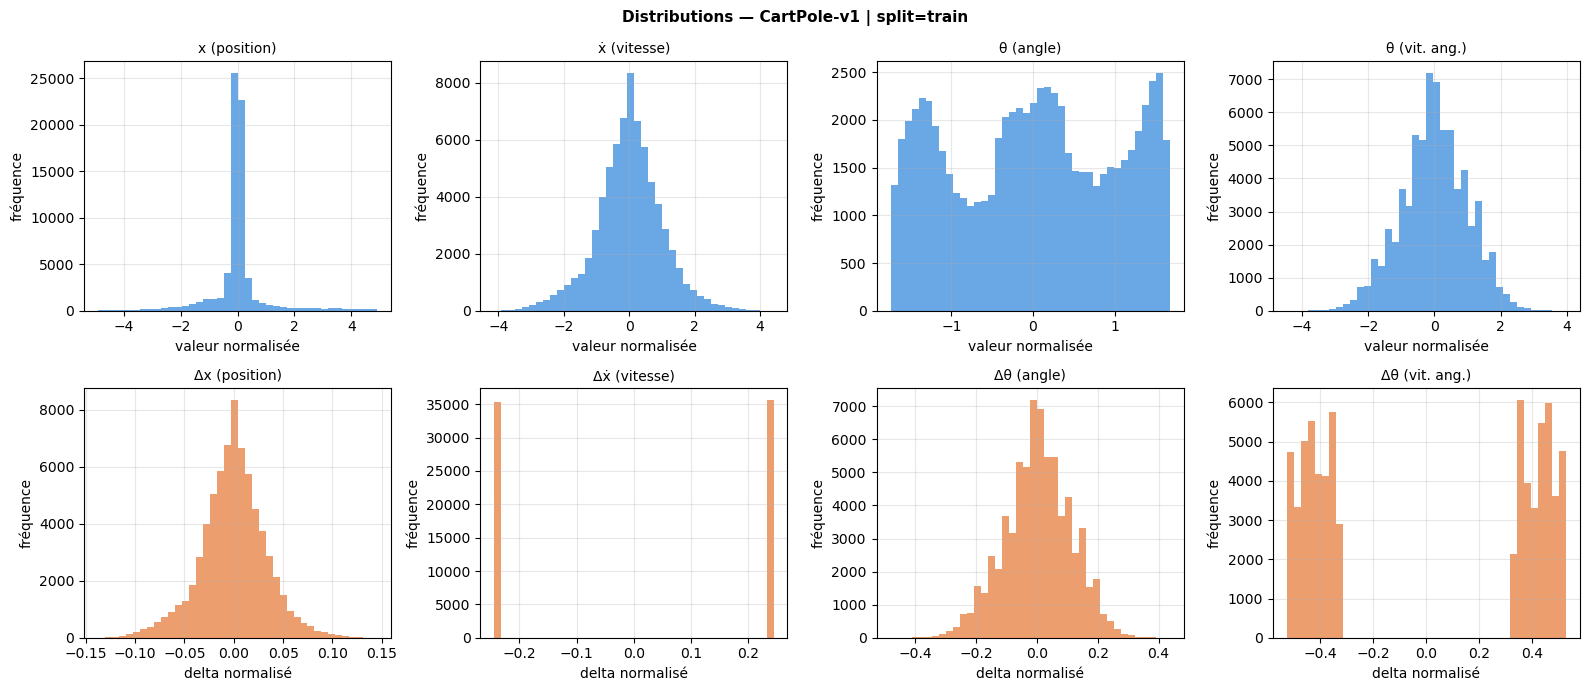

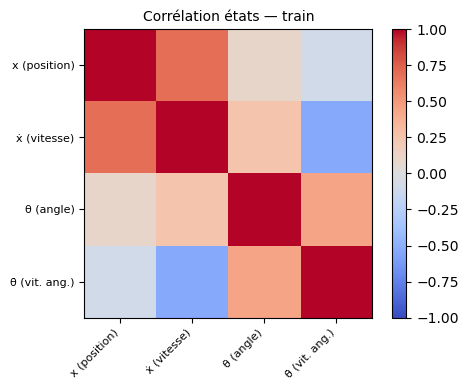

📊 Figures sauvegardées


In [ ]:
def analyze_dataset(S, A, SN, split_name="train", save_dir=SAVE_DIR):
    """Affiche des statistiques et visualise les distributions."""
    print(f"\n--- Statistiques des états ({split_name}) ---")
    for i, name in enumerate(STATE_LABELS):
        print(f"  {name:22s}  min={S[:,i].min():.3f}  max={S[:,i].max():.3f}  "
              f"mean={S[:,i].mean():.3f}  std={S[:,i].std():.3f}")

    action_counts = np.bincount(A.reshape(-1).astype(np.int64), minlength=ACTION_DIM)
    print(f"\nActions : " + " | ".join(f"{ACTION_LABELS[i]}={action_counts[i]:,}" for i in range(ACTION_DIM)))

    n_dims = len(STATE_LABELS)
    fig, axes = plt.subplots(2, n_dims, figsize=(4*n_dims, 7))


    for i, (ax, name) in enumerate(zip(axes[0], STATE_LABELS)):
        ax.hist(S[:, i], bins=40, alpha=0.75, color="#378ADD", edgecolor="none")
        ax.set_title(name, fontsize=10)
        ax.set_xlabel("valeur normalisée"); ax.set_ylabel("fréquence")
        ax.grid(alpha=0.3)


    deltas_raw = SN - S
    for i, (ax, name) in enumerate(zip(axes[1], STATE_LABELS)):
        ax.hist(deltas_raw[:, i], bins=40, alpha=0.75, color="#E87E3E", edgecolor="none")
        ax.set_title(f"Δ{name}", fontsize=10)
        ax.set_xlabel("delta normalisé"); ax.set_ylabel("fréquence")
        ax.grid(alpha=0.3)


    plt.suptitle(f"Distributions — CartPole-v1 | split={split_name}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(save_dir, f"distributions_{split_name}.png")
    plt.savefig(path, dpi=130, bbox_inches="tight"); plt.show()


    fig2, ax2 = plt.subplots(figsize=(5, 4))
    corr = np.corrcoef(S.T)
    im = ax2.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax2.set_xticks(range(n_dims)); ax2.set_yticks(range(n_dims))
    ax2.set_xticklabels(STATE_LABELS, rotation=45, ha="right", fontsize=8)
    ax2.set_yticklabels(STATE_LABELS, fontsize=8)
    plt.colorbar(im, ax=ax2)
    ax2.set_title(f"Corrélation états — {split_name}", fontsize=10)
    plt.tight_layout()
    path2 = os.path.join(save_dir, f"correlation_{split_name}.png")
    plt.savefig(path2, dpi=130, bbox_inches="tight"); plt.show()
    print(f"📊 Figures sauvegardées")


analyze_dataset(S_tr_n, A_tr, NS_tr_n, split_name="train")

## 13. Métadonnées

In [ ]:
def convert_numpy(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")


metadata = {
    "env_name"        : ENV_NAME,
    "collection_date" : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "total_steps"     : int(step_count),
    "total_episodes"  : int(episode_count),
    "n_steps"         : N_STEPS,
    "trained_ratio"   : TRAINED_RATIO,
    "seed"            : SEED,
    "state_dim"       : STATE_DIM,
    "action_dim"      : ACTION_DIM,
    "state_labels"    : STATE_LABELS,
    "action_labels"   : ACTION_LABELS,
    "split"           : {"train":TRAIN_RATIO,"val":VAL_RATIO,"test":TEST_RATIO},
    "n_episodes"      : {"train":len(train_ep_idx),"val":len(val_ep_idx),"test":len(test_ep_idx)},
    "n_steps_per_split": {"train":int(len(S_tr)),"val":int(len(S_va)),"test":int(len(S_te))},
    "normalization"   : "z-score (mean/std from train only)",
    "policy"          : f"mixed (DQN ε-greedy + random)",
    "reward_stats"    : {"mean":float(np.mean(rewards_log)),"std":float(np.std(rewards_log)),
                          "min":float(np.min(rewards_log)),"max":float(np.max(rewards_log))},
    "files"           : ["transitions.npz","sequences_n5.npz","deltas.npz","scaler.npz"],
}
with open(os.path.join(SAVE_DIR,"metadata.json"),"w") as f:
    json.dump(metadata, f, indent=4, default=convert_numpy)
print("  metadata.json sauvegardé")
print(json.dumps(metadata, indent=4, default=convert_numpy))

✅ metadata.json sauvegardé
{
    "env_name": "CartPole-v1",
    "collection_date": "2026-06-01 13:34:21",
    "total_steps": 100000,
    "total_episodes": 3579,
    "n_steps": 5,
    "trained_ratio": 0.6,
    "seed": 42,
    "state_dim": 4,
    "action_dim": 2,
    "state_labels": [
        "x (position)",
        "\u1e8b (vitesse)",
        "\u03b8 (angle)",
        "\u03b8\u0307 (vit. ang.)"
    ],
    "action_labels": [
        "gauche (0)",
        "droite (1)"
    ],
    "split": {
        "train": 0.7,
        "val": 0.1,
        "test": 0.2
    },
    "n_episodes": {
        "train": 2505,
        "val": 357,
        "test": 717
    },
    "n_steps_per_split": {
        "train": 70871,
        "val": 9522,
        "test": 19604
    },
    "normalization": "z-score (mean/std from train only)",
    "policy": "mixed (DQN \u03b5-greedy + random)",
    "reward_stats": {
        "mean": 27.939927354009498,
        "std": 27.604712295692273,
        "min": 8.0,
        "max": 443.0
   